# Effects of dataset height and width on DP sums

Differential privacy will work best on datasets that are "tall and skinny":
They have a lot of rows, but only a small number of columns under analysis.
Having more rows means that the contribution of any particular row is smaller,
and having fewer columns reveals less information for every row.

But how tall is tall enough? And how many columns is too many columns?
In this notebook we'll demonstrate the effects of DP on different kinds of datasets,
so you you can make an informed decision about whether DP is an appropriate technology.

In [5]:
import matplotlib.pyplot as plt
import opendp.prelude as dp
import polars as pl

# The OpenDP team is working to vet the core algorithms.
# Until that is complete we need to opt-in to use these features.
dp.enable_features("contrib")

In [6]:
def make_fives_lf(rows, cols):
    """
    Makes a lazyframe with the specified rows and column, filled with fives.
    """
    return pl.LazyFrame({f"col_{i + 1}": (5 for _ in range(rows)) for i in range(cols)})

In [ ]:
results = {}
accuracies = {}


def key(rows, cols):
    return f"{rows=} {cols=}"


max_rows_log_10 = 5
max_cols_log_2 = 5
plus_minus = 5

for rows_log_10 in range(1, max_rows_log_10):
    rows = 10**rows_log_10
    for cols_log_2 in range(max_cols_log_2):
        cols = 2**cols_log_2
        context = dp.Context.compositor(
            data=make_fives_lf(rows=rows, cols=cols),
            privacy_unit=dp.unit_of(contributions=1),
            privacy_loss=dp.loss_of(epsilon=1.0, delta=0),
            split_by_weights=[1],
            margins=[
                dp.polars.Margin(max_length=rows),
            ],
        )

        col_queries = [
            pl.col(f"col_{i + 1}").dp.sum((5 - plus_minus, 5 + plus_minus))
            for i in range(cols)
        ]
        query = context.query().select(*col_queries)
        accuracy = query.summarize(alpha=0.05)["accuracy"][0]

        k = key(rows, cols)
        accuracies[k] = accuracy
        print(key(rows, cols), accuracy)
        results[k] = query.release().collect()

rows=10 cols=1 30.444827940403663
rows=10 cols=2 60.408396122013016
rows=10 cols=4 120.32616602353652
rows=10 cols=8 240.15701939449175
rows=10 cols=16 479.8163825199104
rows=100 cols=1 30.444827940403663
rows=100 cols=2 60.408396122013016
rows=100 cols=4 120.32616602353652
rows=100 cols=8 240.15701939449175
rows=100 cols=16 479.8163825199104
rows=1000 cols=1 30.444827940403663
rows=1000 cols=2 60.408396122013016
rows=1000 cols=4 120.32616602353652
rows=1000 cols=8 240.15701939449175
rows=1000 cols=16 479.8163825199104
rows=10000 cols=1 30.444827940403663
rows=10000 cols=2 60.408396122013016
rows=10000 cols=4 120.32616602353652
rows=10000 cols=8 240.15701939449175
rows=10000 cols=16 479.8163825199104


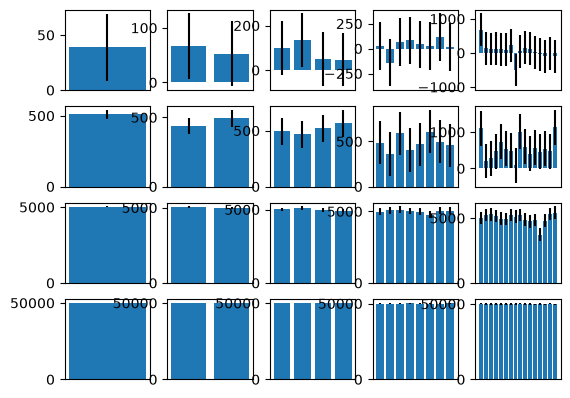

In [16]:
fig, axs = plt.subplots(max_rows_log_10 - 1, max_cols_log_2)

for rows_log_10 in range(1, max_rows_log_10):
    rows = 10**rows_log_10
    for cols_log_2 in range(max_cols_log_2):
        cols = 2**cols_log_2
        values = results[key(rows, cols)].to_dicts()[0].values()
        ax = axs[rows_log_10 - 1, cols_log_2]
        ax.bar(range(cols), values, yerr=accuracies[key(rows, cols)])
        ax.set_xticks([])

plt.show()